# Decoding repeated image trials with population normalization

This notebook loads the repeated-presentation raster data following `self_consistency_dev.ipynb`, selects a balanced image subset, and measures nearest-centroid decoding over time. Cross-validation is over repetitions: in each fold, one repetition of every selected image is held out and all remaining repetitions are used for training.

In addition to accuracy, every held-out trial retains its complete centroid-distance vector, signed nearest-competitor margin, normalized margin, and correct-class rank. The preprocessing options remove population-vector information through L2 norm division, feature centering as in `cosine_cnt`, and mean centering as in `correlation`.

In [1]:
import os
import sys
import yaml
from dataclasses import dataclass

import h5py
import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
if ENV not in config:
    raise KeyError(f"MY_ENV={ENV!r} is not in config.yaml. Available environments: {list(config)}")
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
if "useful_stuff_path" in paths:
    sys.path.append(paths["useful_stuff_path"])

from useful_stuff.general_utils.utils import TimeSeries
from project_specific_utils.dataloader import decode_matlab_strings
from II_analyses.decoding import (
    PREPROCESSING_CONFIGS,
    crossvalidate_decoding_over_repetitions,
    find_margin_only_differences,
    make_repetition_tensor,
    paired_normalization_statistics,
    select_balanced_images,
)

In [2]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313to21"
    new_fs: int = 100
    n_images: int = 50
    min_repetitions: int = 4
    max_cv_folds: int | None = 5  # set to None to use every repetition fold
    random_state: int | None = None
    classifier: str = "nearest_centroid"  # margins require "nearest_centroid"
    margin_eps: float = 1e-12
    statistics_baseline: str = "raw"
    statistics_alpha: float = 0.05

cfg = Cfg()

## Load repeated trials

The next cell mirrors the explicit loading in `self_consistency_dev.ipynb`: `rasters` is converted to `(neurons, time, trials)`, image names are decoded from the MATLAB file, and the raster is resampled to `cfg.new_fs`.


In [3]:
rasters_path = f"{paths['data_path']}/data/rasters_{cfg.monkey_name}_{cfg.date}.mat"
with h5py.File(rasters_path, "r") as f:
    rasters = f["rasters"][:]

rasters = rasters[:, :300, :].T.astype(np.float32)  # neurons x time x trials, as in self_consistency_dev

allimgs_path = f"{paths['data_path']}/data/allimages_{cfg.monkey_name}_{cfg.date}.mat"
with h5py.File(allimgs_path, "r") as f:
    try:
        refs = f["allimages"][:]
    except KeyError:
        refs = f["uniqueImage"][:]
    monkey_presentation_order = decode_matlab_strings(f, refs)

monkey_presentation_order = np.asarray(monkey_presentation_order, dtype=object)
name_to_indices = {
    name: np.where(monkey_presentation_order == name)[0].tolist()
    for name in np.unique(monkey_presentation_order)
}

rasters_ts = TimeSeries(rasters, 1000)
rasters_ts.resample(cfg.new_fs)
rasters = rasters_ts.get_array().astype(np.float32)
fs = rasters_ts.get_fs()
time_s = np.arange(rasters.shape[1]) / fs

print("rasters:", rasters.shape, "neurons x time x trials")
print("images:", len(name_to_indices), "fs:", fs)
print("repetitions per image: min", min(map(len, name_to_indices.values())), "max", max(map(len, name_to_indices.values())))


rasters: (383, 30, 14840) neurons x time x trials
images: 776 fs: 100
repetitions per image: min 16 max 23


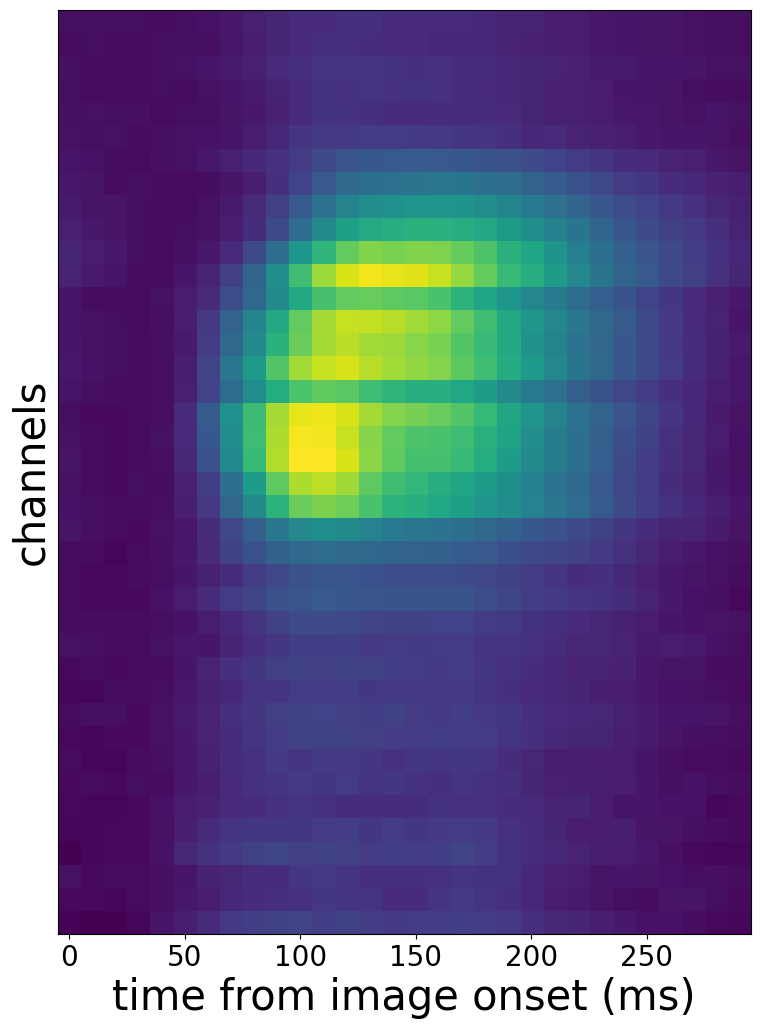

In [21]:
plt.figure(figsize=(20,12))
plt.imshow(np.mean(rasters[290:330, :,:], axis=2))
plt.ylabel("channels", fontsize=30)
plt.xlabel("time from image onset (ms)", fontsize=30)
plt.yticks([])
plt.xticks(
    [0, 5, 10, 15, 20, 25],
    [0, 50, 100, 150, 200, 250], fontsize=20
);

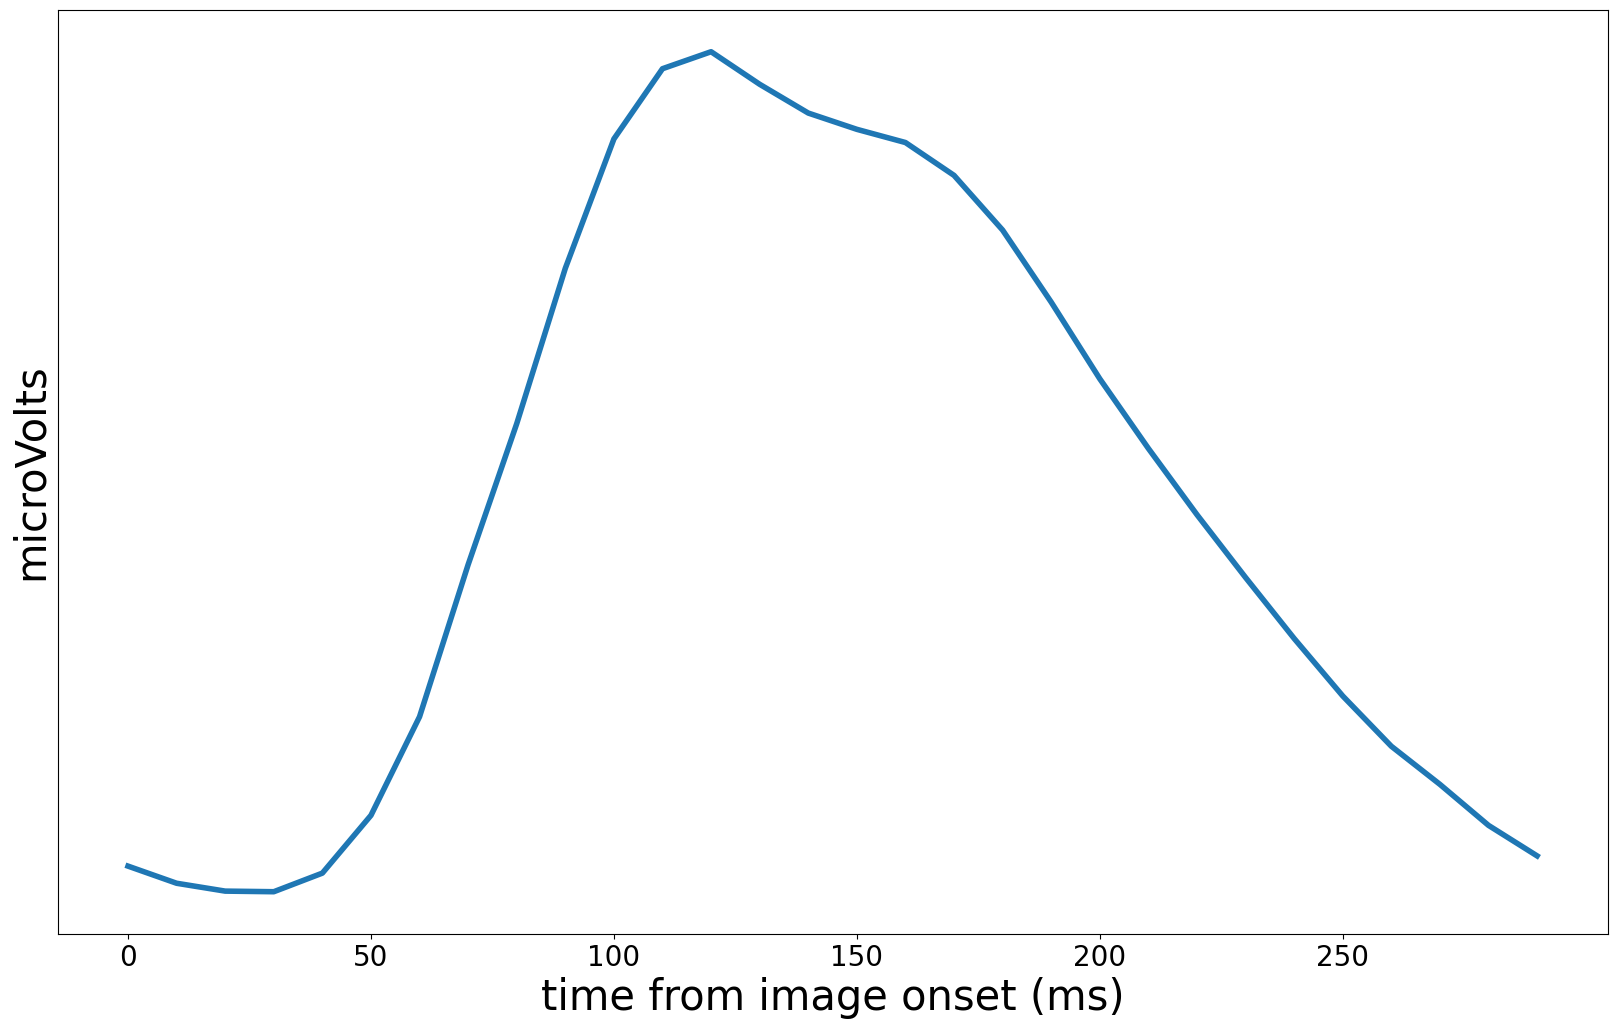

In [26]:
plt.figure(figsize=(20,12))
plt.plot(np.mean(rasters[290:330, :,:], axis=(0,2)), linewidth=4)
plt.ylabel("microVolts", fontsize=30)
plt.xlabel("time from image onset (ms)", fontsize=30)
plt.yticks([])
plt.xticks(
    [0, 5, 10, 15, 20, 25],
    [0, 50, 100, 150, 200, 250], fontsize=20
);

## Build a balanced repeated-trial subset

Each selected image contributes the same number of repetitions. The repetitions are shuffled within image, then fold `r` tests repetition `r` for every image and trains on the other repetitions.


In [4]:
selected_names, n_repetitions = select_balanced_images(
    name_to_indices,
    n_images=cfg.n_images,
    min_repetitions=cfg.min_repetitions,
    random_state=cfg.random_state,
)
if cfg.max_cv_folds is not None:
    n_repetitions = min(n_repetitions, cfg.max_cv_folds)

X_rep, y_images, selected_trial_indices = make_repetition_tensor(
    rasters,
    name_to_indices,
    selected_names,
    n_repetitions=n_repetitions,
    random_state=cfg.random_state,
)

print("selected images:", len(selected_names))
print("repetitions used per image / CV folds:", n_repetitions)
print("X_rep:", X_rep.shape, "images x repetitions x neurons x time")

selected images: 50
repetitions used per image / CV folds: 5
X_rep: (50, 5, 383, 30) images x repetitions x neurons x time


## Preprocessing and decoder outputs

Reusable decoding functions live in `II_analyses.decoding`. `feature_center` is fitted on training samples only and then applied to train and test data. `mean_center` and `normalize` operate on each population vector independently. The transformation order matches `preprocess_population_vectors` in `II_analyses.static_dyn`: feature center, mean center, then L2 normalize.

The nearest-centroid decoder continues to use squared Euclidean distance after preprocessing. Its output now retains predictions and all centroid distances with shape `(folds, time, held-out images, classes)`. Summary metrics are computed from those outputs in a separate step inside the backwards-compatible wrapper.

In [5]:
for label, preprocessing in PREPROCESSING_CONFIGS.items():
    print(f"{label:20s} {preprocessing}")

if cfg.classifier != "nearest_centroid":
    print("Centroid margins are unavailable for this classifier; accuracy will still run.")

raw                  {'normalize': False, 'feature_center': False, 'mean_center': False}
norm                 {'normalize': True, 'feature_center': False, 'mean_center': False}
feature_center       {'normalize': False, 'feature_center': True, 'mean_center': False}
feature_center_norm  {'normalize': True, 'feature_center': True, 'mean_center': False}
mean_center          {'normalize': False, 'feature_center': False, 'mean_center': True}
mean_center_norm     {'normalize': True, 'feature_center': False, 'mean_center': True}


## Cross-validate over repetitions

Decoder computation happens only once per normalization. The returned result combines raw held-out outputs with backwards-compatible accuracy keys and the new trial-level and aggregate margin metrics.

In [6]:
results = {}
for label, preprocessing in PREPROCESSING_CONFIGS.items():
    print(f"running {label} ...")
    results[label] = crossvalidate_decoding_over_repetitions(
        X_rep,
        preprocessing=preprocessing,
        classifier=cfg.classifier,
        margin_eps=cfg.margin_eps,
    )

print("done")

running raw ...
running norm ...
running feature_center ...
running feature_center_norm ...
running mean_center ...
running mean_center_norm ...
done


## Trial-level outputs and aggregate summaries

`margin` and `margin_norm` retain their full `(folds, time, held-out images)` distributions. Positive signed margins indicate correct nearest-centroid separation; negative values quantify the severity of errors. `outcome_summary` contains the same summaries for all, correct, and incorrect trials.

In [7]:
example_result = next(iter(results.values()))
print("predictions:", example_result["predictions"].shape, "folds x time x held-out images")
if "centroid_distances" in example_result:
    print("centroid distances:", example_result["centroid_distances"].shape)
    print("margin distribution:", example_result["margin_distribution"].shape)
    print("correct-class rank:", example_result["correct_rank"].shape)

predictions: (5, 30, 50) folds x time x held-out images
centroid distances: (5, 30, 50, 50)
margin distribution: (5, 30, 50)
correct-class rank: (5, 30, 50)


## Accuracy and representational margins over time

Uncertainty bands are SEM across held-out repetition folds, matching the previous accuracy plot. The raw margin remains in squared-distance units; the normalized margin reduces this scale dependence and is the primary comparison.

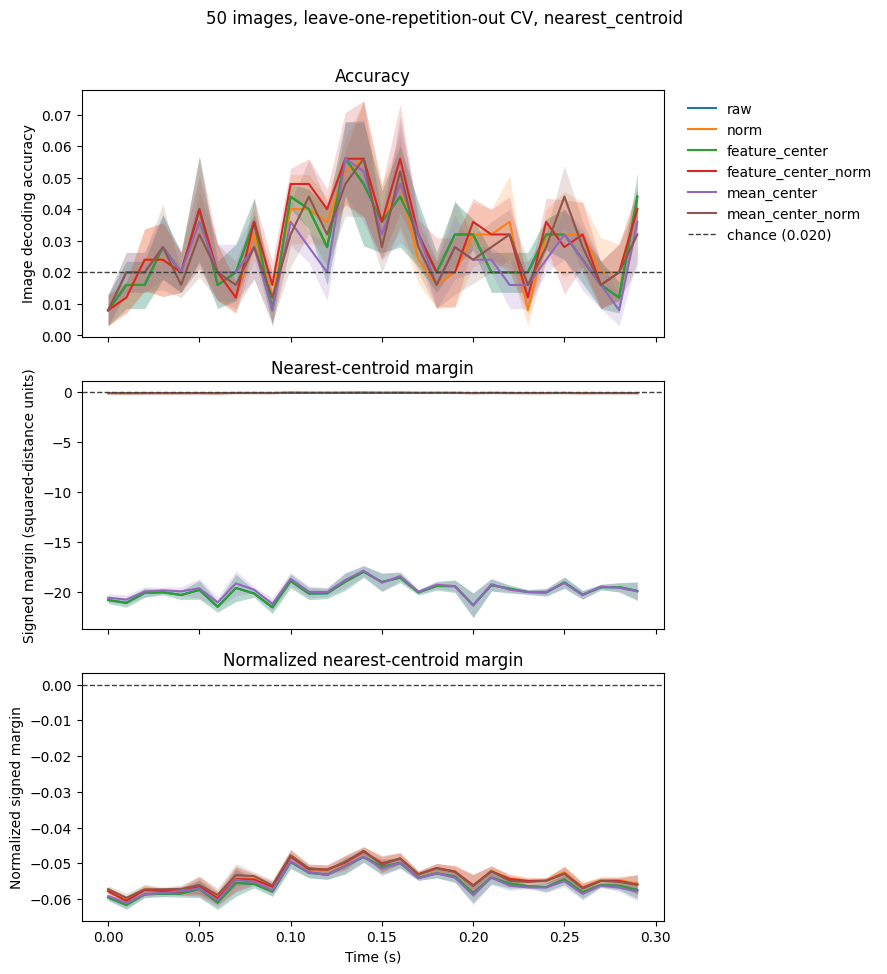

In [8]:
plot_specs = [
    ("mean_accuracy", "sem_accuracy", "Image decoding accuracy", "Accuracy"),
]
if "mean_margin" in example_result:
    plot_specs.extend([
        ("mean_margin", "sem_margin", "Signed margin (squared-distance units)", "Nearest-centroid margin"),
        ("mean_margin_norm", "sem_margin_norm", "Normalized signed margin", "Normalized nearest-centroid margin"),
    ])

fig, axes = plt.subplots(len(plot_specs), 1, figsize=(9, 3.2 * len(plot_specs)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (mean_key, sem_key, ylabel, title) in zip(axes, plot_specs):
    for label, result in results.items():
        mean = result[mean_key]
        sem = result[sem_key]
        line, = ax.plot(time_s, mean, label=label)
        ax.fill_between(
            time_s,
            mean - sem,
            mean + sem,
            color=line.get_color(),
            alpha=0.18,
            linewidth=0,
        )

    if mean_key == "mean_accuracy":
        chance = example_result["chance"]
        ax.axhline(chance, color="0.25", linestyle="--", linewidth=1, label=f"chance ({chance:.3f})")
    else:
        ax.axhline(0, color="0.25", linestyle="--", linewidth=1)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[-1].set_xlabel("Time (s)")
axes[0].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"{cfg.n_images} images, leave-one-repetition-out CV, {cfg.classifier}", y=1.01)
plt.tight_layout()

## Correct and incorrect trial diagnostics

Outcome-conditioned summaries are descriptive. Because normalizations can change which trials are correct, the two subsets are not used as directly paired inferential samples.

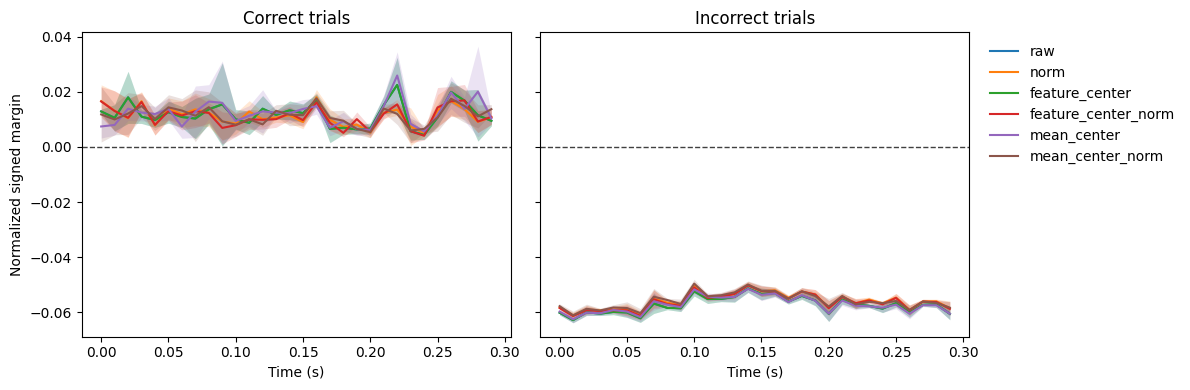

In [9]:
if "mean_margin_norm" in example_result:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
    for ax, outcome in zip(axes, ("correct", "incorrect")):
        for label, result in results.items():
            outcome_result = result["outcome_summary"][outcome]
            mean = outcome_result["mean_margin_norm"]
            sem = outcome_result["sem_margin_norm"]
            line, = ax.plot(time_s, mean, label=label)
            ax.fill_between(
                time_s,
                mean - sem,
                mean + sem,
                color=line.get_color(),
                alpha=0.18,
                linewidth=0,
            )
        ax.axhline(0, color="0.25", linestyle="--", linewidth=1)
        ax.set_xlabel("Time (s)")
        ax.set_title(f"{outcome.capitalize()} trials")

    axes[0].set_ylabel("Normalized signed margin")
    axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

## Paired within-session statistics

Images are averaged within each held-out repetition, and repetition folds are paired across normalizations. The Wilcoxon signed-rank tests below are exploratory for this single session. Benjamini-Hochberg correction is applied across time bins separately for each normalization and metric comparison. Population-level manuscript inference should instead pair session-level effects.

In [10]:
paired_statistics = None
margin_only_findings = []
if "mean_margin" in example_result:
    paired_statistics = paired_normalization_statistics(
        results,
        baseline=cfg.statistics_baseline,
        metrics=("accuracy", "margin", "margin_norm", "correct_rank"),
        alpha=cfg.statistics_alpha,
    )
    margin_only_findings = find_margin_only_differences(
        paired_statistics,
        time_s,
        metric="margin_norm",
    )

    print("FDR-significant time bins by paired metric:")
    for label, comparison in paired_statistics.items():
        significant_counts = {
            metric: int(metric_result["significant"].sum())
            for metric, metric_result in comparison["metrics"].items()
        }
        print(
            f"  {label} vs {comparison['baseline']} | "
            f"equal mean accuracy={int(comparison['accuracy_identical'].sum())}/{len(time_s)} bins | "
            f"identical trial outcomes={int(comparison['accuracy_outcomes_identical'].sum())}/{len(time_s)} bins | "
            f"significant bins={significant_counts}"
        )
    print()

    if margin_only_findings:
        print("Accuracy-identical bins with a significant normalized-margin difference:")
        for finding in margin_only_findings:
            print(
                f"  {finding['normalization']} vs {finding['baseline']} | "
                f"t={finding['time_s']:.3f}s | "
                f"mean difference={finding['mean_difference']:.4f} | "
                f"FDR q={finding['qvalue']:.4g}"
            )
    else:
        print("No time bin had identical accuracy and a significant normalized-margin difference after FDR correction.")

FDR-significant time bins by paired metric:
  norm vs raw | equal mean accuracy=7/30 bins | identical trial outcomes=1/30 bins | significant bins={'accuracy': 0, 'margin': 0, 'margin_norm': 0, 'correct_rank': 0}
  feature_center vs raw | equal mean accuracy=30/30 bins | identical trial outcomes=30/30 bins | significant bins={'accuracy': 0, 'margin': 0, 'margin_norm': 0, 'correct_rank': 0}
  feature_center_norm vs raw | equal mean accuracy=9/30 bins | identical trial outcomes=2/30 bins | significant bins={'accuracy': 0, 'margin': 0, 'margin_norm': 0, 'correct_rank': 0}
  mean_center vs raw | equal mean accuracy=10/30 bins | identical trial outcomes=7/30 bins | significant bins={'accuracy': 0, 'margin': 0, 'margin_norm': 0, 'correct_rank': 0}
  mean_center_norm vs raw | equal mean accuracy=3/30 bins | identical trial outcomes=2/30 bins | significant bins={'accuracy': 0, 'margin': 0, 'margin_norm': 0, 'correct_rank': 0}

No time bin had identical accuracy and a significant normalized-marg

## Time-averaged diagnostics

In [11]:
for label, result in results.items():
    peak_idx = int(np.argmax(result["mean_accuracy"]))
    message = (
        f"{label:20s} peak accuracy={result['mean_accuracy'][peak_idx]:.3f} "
        f"at {time_s[peak_idx]:.3f}s | mean accuracy={result['mean_accuracy'].mean():.3f}"
    )
    if "mean_margin" in result:
        message += (
            f" | mean margin={np.nanmean(result['mean_margin']):.4f}"
            f" | median margin={np.nanmean(result['median_margin']):.4f}"
            f" | normalized margin={np.nanmean(result['mean_margin_norm']):.4f}"
            f" | correct rank={np.nanmean(result['mean_correct_rank']):.2f}"
        )
    print(message)

raw                  peak accuracy=0.056 at 0.130s | mean accuracy=0.028 | mean margin=-19.8535 | median margin=-19.4375 | normalized margin=-0.0555 | correct rank=23.27
norm                 peak accuracy=0.056 at 0.140s | mean accuracy=0.028 | mean margin=-0.1244 | median margin=-0.1233 | normalized margin=-0.0541 | correct rank=23.29
feature_center       peak accuracy=0.056 at 0.130s | mean accuracy=0.028 | mean margin=-19.8535 | median margin=-19.4375 | normalized margin=-0.0555 | correct rank=23.27
feature_center_norm  peak accuracy=0.056 at 0.160s | mean accuracy=0.030 | mean margin=-0.1286 | median margin=-0.1274 | normalized margin=-0.0542 | correct rank=23.21
mean_center          peak accuracy=0.056 at 0.130s | mean accuracy=0.026 | mean margin=-19.7217 | median margin=-19.3096 | normalized margin=-0.0555 | correct rank=23.38
mean_center_norm     peak accuracy=0.056 at 0.140s | mean accuracy=0.028 | mean margin=-0.1261 | median margin=-0.1252 | normalized margin=-0.0540 | corre

## Interpretation and scaling up

The geometric interpretation, statistical cautions, recommended manuscript measure, and possible decoder-independent extensions are documented in [`../REPRESENTATIONAL_MARGINS.md`](../REPRESENTATIONAL_MARGINS.md).

Set `cfg.max_cv_folds = None` for the final analysis so every available repetition contributes, and set `cfg.random_state` to a fixed integer if a random image subset is retained. Feature centering alone is a shared translation and therefore cannot alter Euclidean centroid distances; `raw` and `feature_center` are expected to match exactly. For population-level inference, run the same balanced pipeline for each session, reduce each session to a paired normalization effect in a pre-specified time window (or use an appropriate time-cluster procedure), and treat session rather than image as the inferential unit.